# Pricing and Greek Surfaces

### Libraries

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent / 'src'))

In [2]:
from abc import ABC, abstractmethod
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from option import CallOption, PutOption
from underlying import GeometricBrownianMotion

### Initialisation

In [4]:
np.random.seed(1973)
save_figures = True

Graphing parameters:

In [5]:
mesh_resolution = 1/1000
num_of_samples = 5

In [6]:
start = 1
end = 200
num_points = ((end - start) // start) + 1
spot_axis = np.linspace(start, end, num_points)

Market parameters:

In [7]:
spot = 100 # $100
strike = 100 # $100
maturity = 1 # 1 year
rate = 0.05 # 5%
drift = 0.3 # 30%
sigma = 0.2 # 20%

### Underlying Model

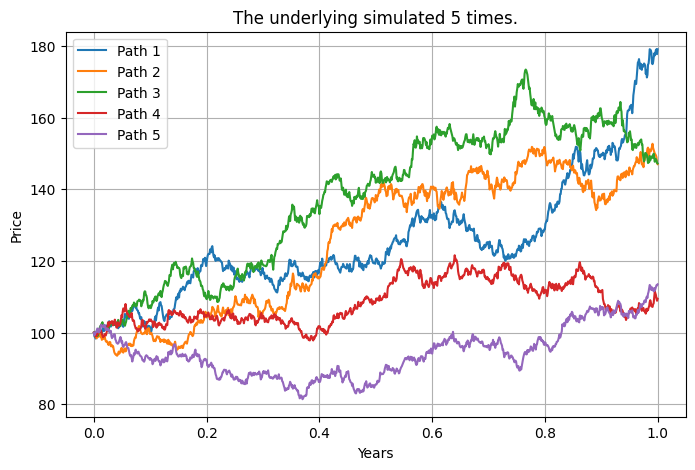

In [8]:
asset = GeometricBrownianMotion(spot, drift, sigma)

paths = asset.simulate(maturity, num_of_samples, mesh_resolution)
time_axis = np.linspace(0, maturity, len(paths[0])) #int(maturity/mesh_resolution)+1

plt.figure(figsize=(8,5))
for j in range(num_of_samples):
    plt.plot(time_axis, paths[j], label=f"Path {j+1}")

plt.title(f"The underlying simulated {num_of_samples} times.")
plt.xlabel("Years")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
if save_figures:
    plt.savefig('../figures/gbm_samples.png')

### Vanilla Options

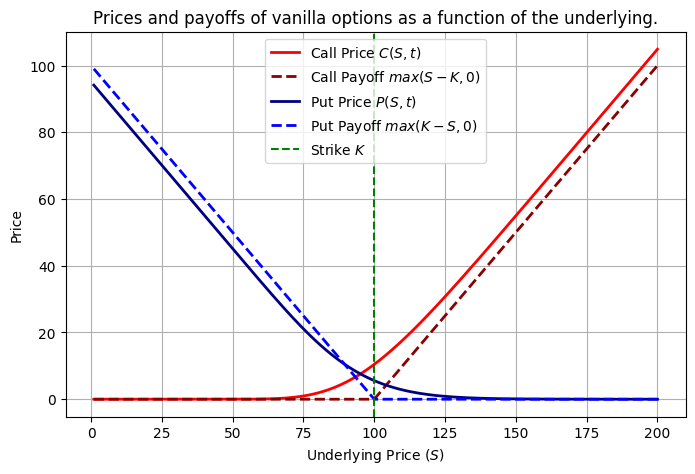

In [9]:
call = CallOption(strike, maturity)
put = PutOption(strike, maturity)

plt.figure(figsize=(8,5))
plt.plot(spot_axis, call.price(spot_axis, 0, rate, sigma), color='red', label=r"Call Price $C(S,t)$", linewidth=2)
plt.plot(spot_axis, call.payoff(spot_axis), '--', color='darkred', label=r"Call Payoff $max(S-K,0)$", linewidth=2)
plt.plot(spot_axis, put.price(spot_axis, 0, rate, sigma), color='navy', label=r"Put Price $P(S,t)$", linewidth=2)
plt.plot(spot_axis, put.payoff(spot_axis), '--', color='blue', label=r"Put Payoff $max(K-S,0)$", linewidth=2)
plt.axvline(strike, color='green', linestyle='--', label=r"Strike $K$")
plt.xlabel(r"Underlying Price ($S$)")
plt.ylabel("Price")
plt.title("Prices and payoffs of vanilla options as a function of the underlying.")
plt.legend()
plt.grid(True)
if save_figures:
    plt.savefig('../figures/put_call.png')

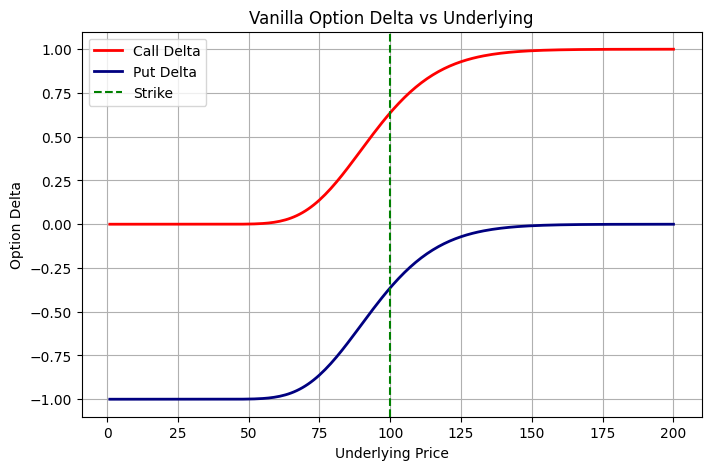

In [10]:
plt.figure(figsize=(8,5))
plt.plot(spot_axis, call.delta(spot_axis, 0, rate, sigma), color='red', label="Call Delta", linewidth=2)
plt.plot(spot_axis, put.delta(spot_axis, 0, rate, sigma), color='navy', label="Put Delta", linewidth=2)
plt.axvline(strike, color='green', linestyle='--', label="Strike")
plt.xlabel("Underlying Price")
plt.ylabel("Option Delta")
plt.title("Vanilla Option Delta vs Underlying")
plt.legend()
plt.grid(True)
if save_figures:
    plt.savefig('../figures/put_call_delta_parity.png')

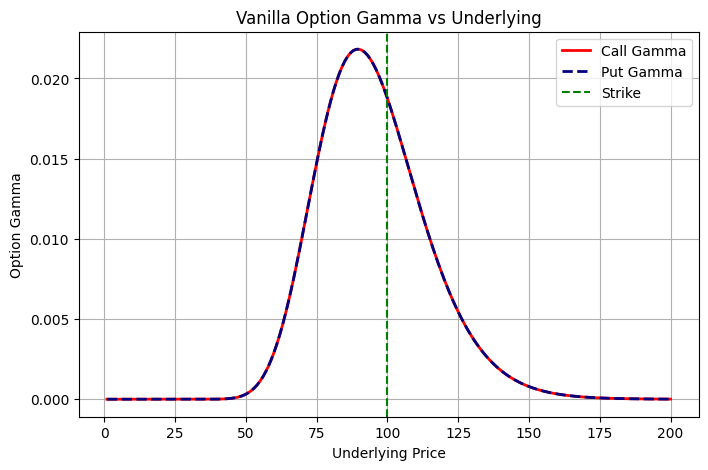

In [11]:
plt.figure(figsize=(8,5))
plt.plot(spot_axis, call.gamma(spot_axis, 0, rate, sigma), color='red', label="Call Gamma", linewidth=2)
plt.plot(spot_axis, put.gamma(spot_axis, 0, rate, sigma), '--', color='navy', label="Put Gamma", linewidth=2)
plt.axvline(strike, color='green', linestyle='--', label="Strike")
plt.xlabel("Underlying Price")
plt.ylabel("Option Gamma")
plt.title("Vanilla Option Gamma vs Underlying")
plt.legend()
plt.grid(True)
if save_figures:
    plt.savefig('../figures/put_call_gamma.png')

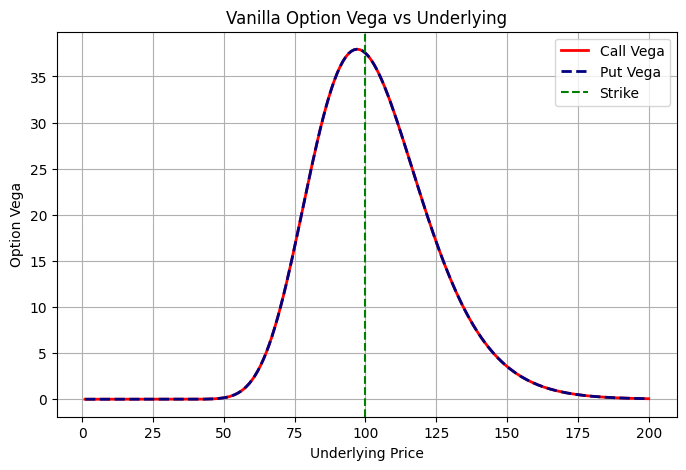

In [12]:
plt.figure(figsize=(8,5))
plt.plot(spot_axis, call.vega(spot_axis, 0, rate, sigma), color='red', label="Call Vega", linewidth=2)
plt.plot(spot_axis, put.vega(spot_axis, 0, rate, sigma), '--', color='navy', label="Put Vega", linewidth=2)
plt.axvline(strike, color='green', linestyle='--', label="Strike")
plt.xlabel("Underlying Price")
plt.ylabel("Option Vega")
plt.title("Vanilla Option Vega vs Underlying")
plt.legend()
plt.grid(True)
if save_figures:
    plt.savefig('../figures/put_call_vega.png')

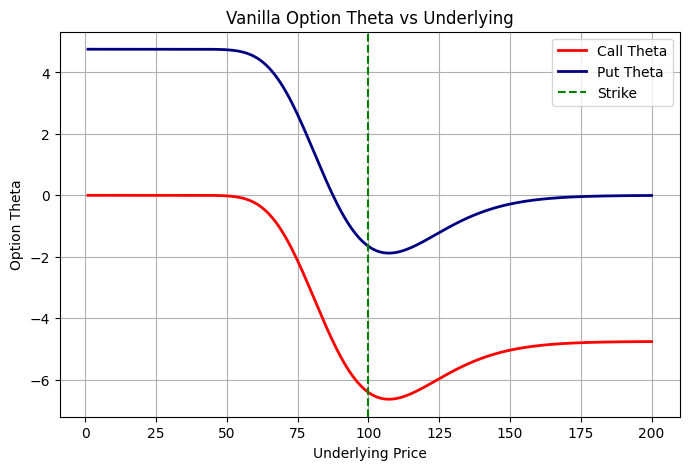

In [13]:
plt.figure(figsize=(8,5))
plt.plot(spot_axis, call.theta(spot_axis, 0, rate, sigma), color='red', label="Call Theta", linewidth=2)
plt.plot(spot_axis, put.theta(spot_axis, 0, rate, sigma), color='navy', label="Put Theta", linewidth=2)
plt.axvline(strike, color='green', linestyle='--', label="Strike")
plt.xlabel("Underlying Price")
plt.ylabel("Option Theta")
plt.title("Vanilla Option Theta vs Underlying")
plt.legend()
plt.grid(True)
if save_figures:
    plt.savefig('../figures/put_call_theta.png')

### Option Spreads

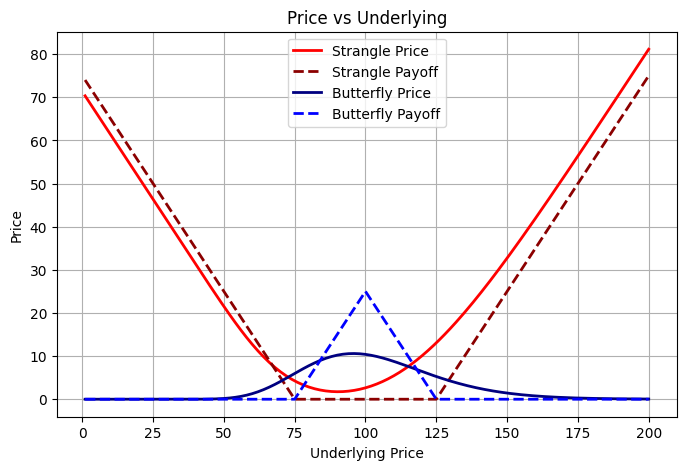

In [14]:
bull_call = CallOption(90,1) - CallOption(110,1)
butterfly = CallOption(75, 1) - 2*CallOption(100, 1) + CallOption(125, 1)
call_condor = CallOption(50,1) - CallOption(60,1) - CallOption(140,1) + CallOption(150,1)
straddle = CallOption(100,1) + PutOption(100,1)
strangle = CallOption(125,1) + PutOption(75,1)

combo_option_1 = strangle
combo_option_2 = butterfly

plt.figure(figsize=(8,5))
plt.plot(spot_axis, combo_option_1.price(spot_axis, 0, rate, sigma), color='red', label="Strangle Price", linewidth=2)
plt.plot(spot_axis, combo_option_1.payoff(spot_axis), '--', color='darkred', label="Strangle Payoff", linewidth=2)
plt.plot(spot_axis, combo_option_2.price(spot_axis, 0, rate, sigma), color='navy', label="Butterfly Price", linewidth=2)
plt.plot(spot_axis, combo_option_2.payoff(spot_axis), '--', color='blue', label="Butterfly Payoff", linewidth=2)
plt.xlabel("Underlying Price")
plt.ylabel("Price")
plt.title("Price vs Underlying")
plt.legend()
plt.grid(True)
if save_figures:
    plt.savefig('../figures/linear_options.png')

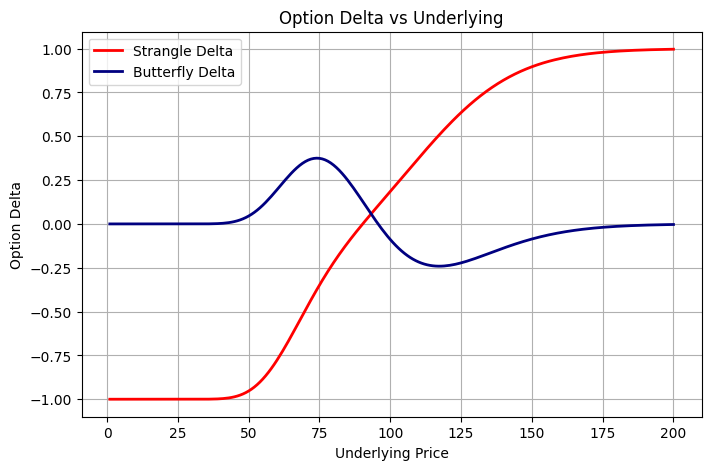

In [15]:
plt.figure(figsize=(8,5))
plt.plot(spot_axis, combo_option_1.delta(spot_axis, 0, rate, sigma), color='red', label="Strangle Delta", linewidth=2)
plt.plot(spot_axis, combo_option_2.delta(spot_axis, 0, rate, sigma), color='navy', label="Butterfly Delta", linewidth=2)
plt.xlabel("Underlying Price")
plt.ylabel("Option Delta")
plt.title("Option Delta vs Underlying")
plt.legend()
plt.grid(True)
if save_figures:
    plt.savefig('../figures/linear_option_deltas.png')

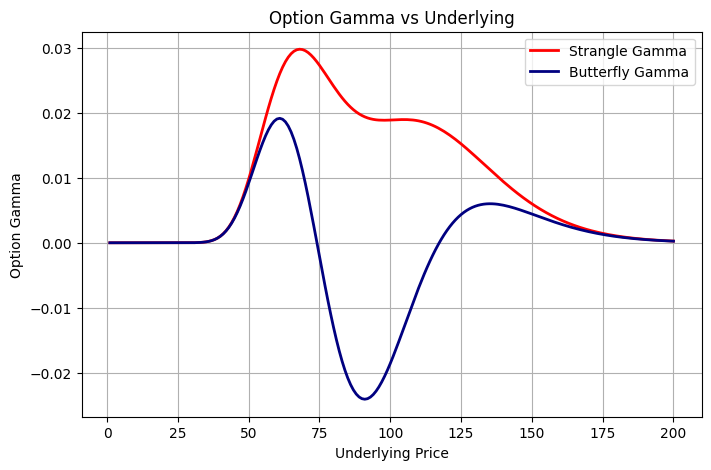

In [16]:
plt.figure(figsize=(8,5))
plt.plot(spot_axis, combo_option_1.gamma(spot_axis, 0, rate, sigma), color='red', label="Strangle Gamma", linewidth=2)
plt.plot(spot_axis, combo_option_2.gamma(spot_axis, 0, rate, sigma), color='navy', label="Butterfly Gamma", linewidth=2)
plt.xlabel("Underlying Price")
plt.ylabel("Option Gamma")
plt.title("Option Gamma vs Underlying")
plt.legend()
plt.grid(True)
if save_figures:
    plt.savefig('../figures/linear_option_gammas.png')

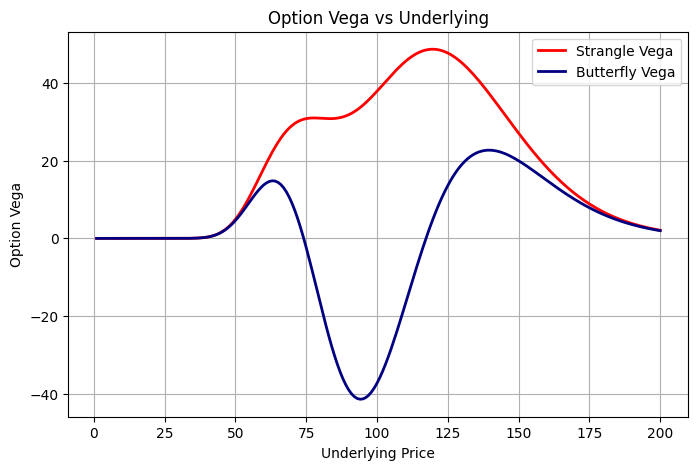

In [17]:
plt.figure(figsize=(8,5))
plt.plot(spot_axis, combo_option_1.vega(spot_axis, 0, rate, sigma), color='red', label="Strangle Vega", linewidth=2)
plt.plot(spot_axis, combo_option_2.vega(spot_axis, 0, rate, sigma), color='navy', label="Butterfly Vega", linewidth=2)
plt.xlabel("Underlying Price")
plt.ylabel("Option Vega")
plt.title("Option Vega vs Underlying")
plt.legend()
plt.grid(True)
if save_figures:
    plt.savefig('../figures/linear_option_vegas.png')

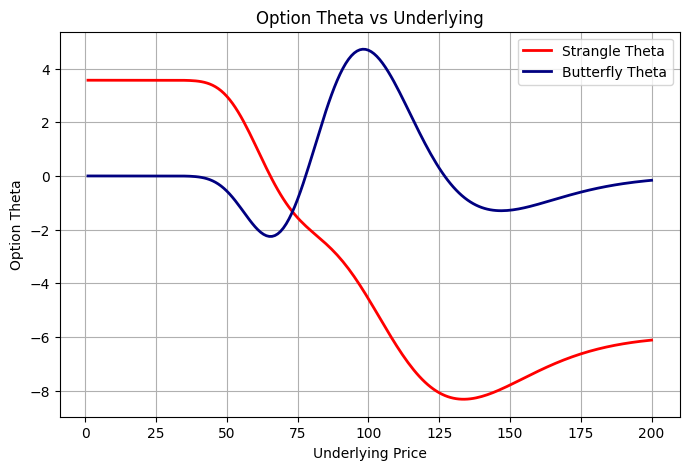

In [18]:
plt.figure(figsize=(8,5))
plt.plot(spot_axis, combo_option_1.theta(spot_axis, 0, rate, sigma), color='red', label="Strangle Theta", linewidth=2)
plt.plot(spot_axis, combo_option_2.theta(spot_axis, 0, rate, sigma), color='navy', label="Butterfly Theta", linewidth=2)
plt.xlabel("Underlying Price")
plt.ylabel("Option Theta")
plt.title("Option Theta vs Underlying")
plt.legend()
plt.grid(True)
if save_figures:
    plt.savefig('../figures/linear_option_thetas.png')